In [13]:
# ------------------------------
# LINEAR REGRESSION with SCALING + 5-FOLD CV
# ------------------------------

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error,accuracy_score

# ------------------------------
# 1. LOAD DATA
# ------------------------------
data = pd.read_csv('loan_approval_dataset.csv')

df = pd.DataFrame(data)

# ------------------------------
# 2. ENCODING
# ------------------------------
le = LabelEncoder()
df[" education"] = le.fit_transform(df[" education"])
df[" self_employed"] = le.fit_transform(df[" self_employed"])
df[" loan_status"] = le.fit_transform(df[" loan_status"])

# ------------------------------
# 3. FEATURES AND TARGET
# ------------------------------
X = df[[
    " no_of_dependents", " education", " self_employed", " income_annum",
    " loan_term", " cibil_score", " residential_assets_value",
    " commercial_assets_value", " luxury_assets_value", " bank_asset_value"
]]
y = df[" loan_amount"]

# ------------------------------
# 4. STANDARDIZATION
# ------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------
# 5. TRAIN-TEST SPLIT
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# ------------------------------
# 6. MODEL TRAINING
# ------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ------------------------------
# 7. PREDICTION & METRICS
# ------------------------------
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("R2 Score:", r2)
print("Mean Squared Error:", mse)

# ------------------------------
# 8. 5-FOLD CROSS VALIDATION
# ------------------------------
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_scaled, y, cv=kfold, scoring="r2")
print("5-Fold CV R2 Scores:", cv_scores)
print("Mean CV R2:", np.mean(cv_scores))


R2 Score: 0.8551716657964047
Mean Squared Error: 11544982400509.373
5-Fold CV R2 Scores: [0.85139807 0.85164312 0.86965183 0.86942843 0.85341386]
Mean CV R2: 0.8591070622855822


In [7]:
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: R² = {score:.4f}")

Fold 1: R² = 0.8514
Fold 2: R² = 0.8516
Fold 3: R² = 0.8697
Fold 4: R² = 0.8694
Fold 5: R² = 0.8534


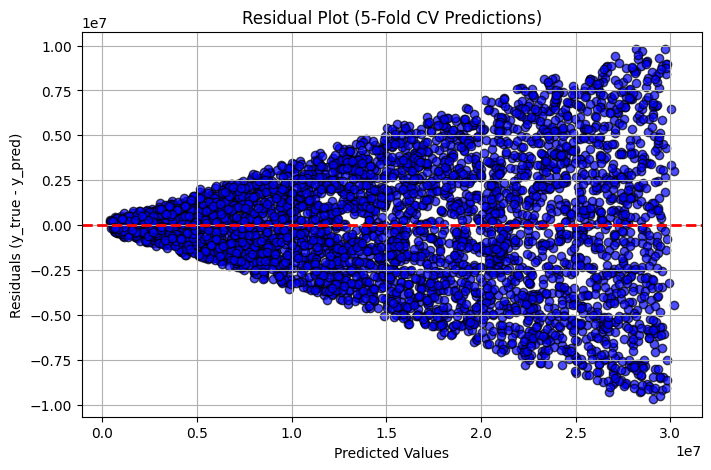

In [10]:
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt

# Get cross-validated predictions for residual analysis
y_pred = cross_val_predict(model, X_scaled, y, cv=5)

# Compute residuals
residuals = y - y_pred

# Residual Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, color="blue", edgecolor="k", alpha=0.7)
plt.axhline(0, color="red", linestyle="--", linewidth=2)
plt.title("Residual Plot (5-Fold CV Predictions)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (y_true - y_pred)")
plt.grid(True)
plt.show()


<Axes: xlabel=' loan_amount'>

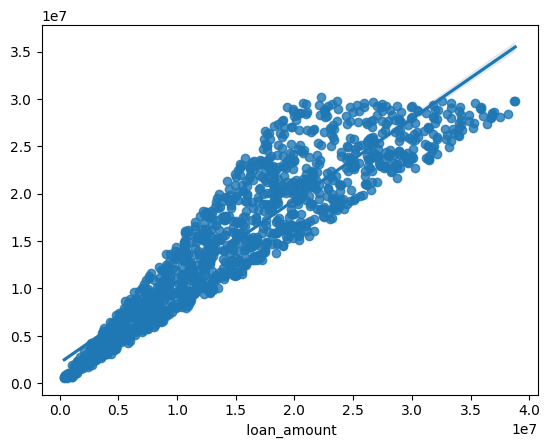

In [15]:
import seaborn as sns
sns.regplot(x=y_test,y=y_pred)

<Axes: xlabel=' no_of_dependents'>

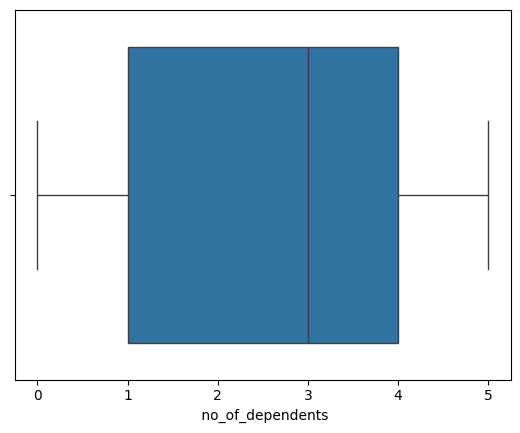

In [17]:
sns.boxplot(data=df,x=df[' no_of_dependents'])

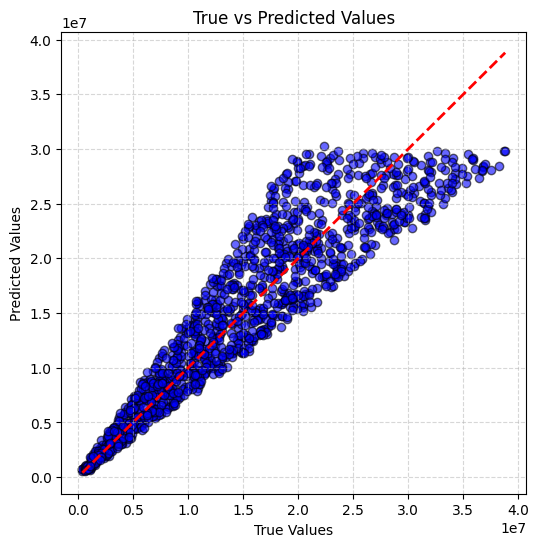

In [18]:
import matplotlib.pyplot as plt

# True vs Predicted Scatter Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [1]:
import pandas as pd
import numpy as np
data = {
    "loan_id": [1,2,3,4,5,6,7],
    "no_of_dependents": [np.nan,0,3,3,5,0,5],
    "education": ["Graduate","Not Graduate","Graduate","Graduate","Not Graduate","Graduate","Graduate"],
    "self_employed": ["No","Yes","No","No","Yes","Yes","No"],
    "income_annum": [9600000,4100000,9100000,8200000,9800000,4800000,8700000],
    "loan_amount": [29900000,12200000,29700000,30700000,24200000,13500000,33000000],
    "loan_term": [12,8,20,8,20,10,4],
    "cibil_score": [778,417,506,467,382,319,678],
    "residential_assets_value": [2400000,2700000,7100000,18200000,12400000,6800000,22500000],
    "commercial_assets_value": [17600000,2200000,4500000,3300000,8200000,8300000,14800000],
    "luxury_assets_value": [22700000,8800000,33300000,23300000,29400000,13700000,29200000],
    "bank_asset_value": [8000000,3300000,12800000,7900000,5000000,5100000,4300000],
    "loan_status": ["Approved","Rejected","Rejected","Rejected","Rejected","Rejected","Approved"]
}

df = pd.DataFrame(data)

In [27]:
num_colmn = df.select_dtypes(
include=['int64', 'float64']
).columns
print(num_colmn)

Index(['loan_id', 'no_of_dependents', 'income_annum', 'loan_amount',
       'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'],
      dtype='object')


In [2]:
df.isnull().sum()

loan_id                     0
no_of_dependents            1
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [3]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["education"] = le.fit_transform(df["education"])
df["self_employed"] = le.fit_transform(df["self_employed"])
df["loan_status"] = le.fit_transform(df["loan_status"])
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,NaN,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0.0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3.0,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3.0,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5.0,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [4]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,NaN,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0.0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3.0,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3.0,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5.0,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [8]:
df['no_of_dependents']=df['no_of_dependents'].fillna(df['no_of_dependents'].mean())
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2.666667,0.285714,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0.000000,1.000000,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3.000000,0.285714,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3.000000,0.285714,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5.000000,1.000000,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1
5,6,0.000000,0.285714,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,1
6,7,5.000000,0.285714,0,8700000,33000000,4,678,22500000,14800000,29200000,4300000,0


In [9]:
df['education']=df['education'].replace(0,df['education'].mean())

In [10]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2.666667,0.285714,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0.000000,1.000000,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3.000000,0.285714,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3.000000,0.285714,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5.000000,1.000000,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1
5,6,0.000000,0.285714,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,1
6,7,5.000000,0.285714,0,8700000,33000000,4,678,22500000,14800000,29200000,4300000,0
